<a href="https://colab.research.google.com/github/ovi-saha/MSCS_634_Lab_5/blob/main/MSCS_634_Lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lab 5: Clustering Techniques Using DBSCAN and Hierarchical Clustering   
Avijit Saha  
Advanced Big Data and Data Mining (MSCS-634-M20)  
Dr. Satish Penmatsa  
March 12, 2026

## Step 1: Data Preparation and Exploration
In this step, I load the Wine dataset, explore its statistical properties, and standardize the features. Standardization is essential because clustering algorithms are distance-based; without it, features with larger numerical ranges (like Magnesium) would dominate those with smaller ranges.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score

# Load the dataset
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Exploration
print("--- Dataset Head ---")
print(df.head())
print("\n--- Dataset Info ---")
print(df.info())
print("\n--- Statistical Summary ---")
print(df.describe())

# Standardization
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
print("\nData successfully standardized.")

--- Dataset Head ---
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline 

##Step 2: Hierarchical Clustering

We apply Agglomerative Hierarchical Clustering. We use a Dendrogram to visualize the nested structure of the clusters and then apply the algorithm using k=3 (reflecting the known wine classes).

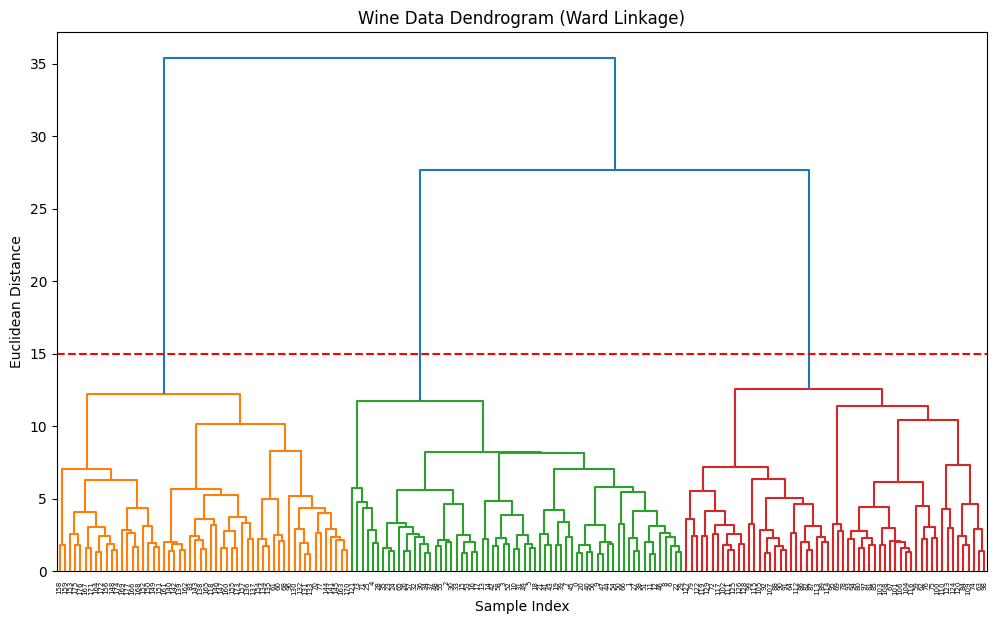

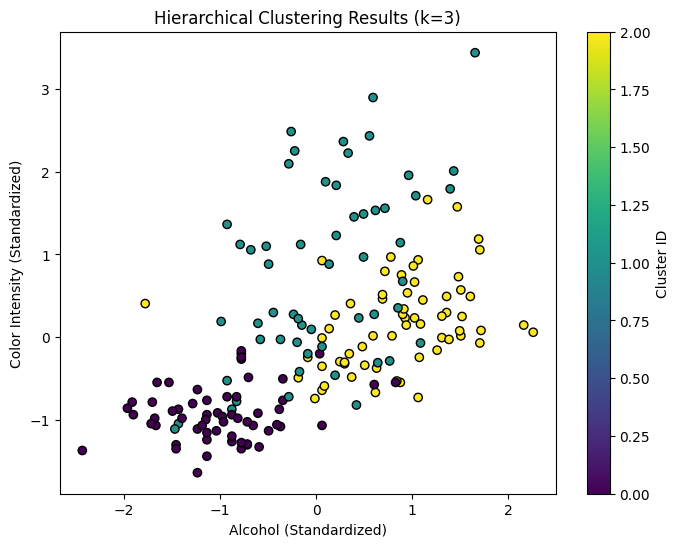

In [13]:
# 1. Generate Dendrogram
plt.figure(figsize=(12, 7))
plt.title("Wine Data Dendrogram (Ward Linkage)")
# 'ward' minimizes the variance of the clusters being merged
Z = linkage(scaled_data, method='ward')
dendrogram(Z)
plt.axhline(y=15, color='r', linestyle='--')
plt.xlabel("Sample Index")
plt.ylabel("Euclidean Distance")
plt.show()

# 2. Apply Agglomerative Clustering
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
hc_labels = hc.fit_predict(scaled_data)

# 3. Visualization (Alcohol vs Color Intensity)
plt.figure(figsize=(8, 6))
plt.scatter(scaled_data[:, 0], scaled_data[:, 9], c=hc_labels, cmap='viridis', edgecolors='k')
plt.title("Hierarchical Clustering Results (k=3)")
plt.xlabel("Alcohol (Standardized)")
plt.ylabel("Color Intensity (Standardized)")
plt.colorbar(label='Cluster ID')
plt.show()

## Step 3: DBSCAN Clustering
In this step, we apply the DBSCAN (Density-Based Spatial Clustering of Applications with Noise) algorithm. Unlike Hierarchical clustering, DBSCAN does not require us to specify the number of clusters in advance; instead, it relies on density.

Parameters Used:

  - **eps (2.6):** The maximum distance between two samples for one to be considered as in the neighborhood of the other.

  - **min_samples (4):** The number of samples in a neighborhood for a point to be considered a core point.

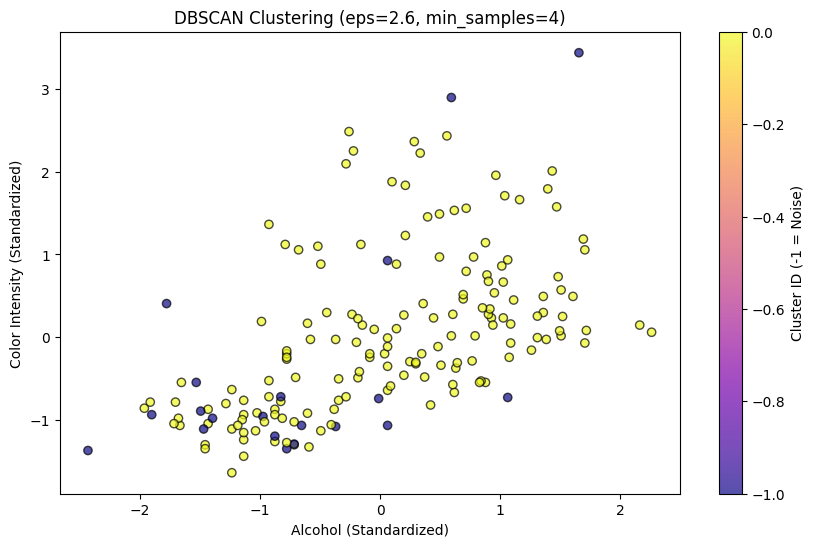

--- DBSCAN Evaluation Metrics ---
Silhouette Score: 0.161
Homogeneity Score: 0.052
Completeness Score: 0.161

--- Cluster Summary ---
Noise Points (Outliers): 20
Cluster 0: 158 points


In [14]:
# Apply DBSCAN
dbscan = DBSCAN(eps=2.6, min_samples=4)
db_labels = dbscan.fit_predict(scaled_data)

# Visualization of Results
plt.figure(figsize=(10, 6))
# Using Alcohol (0) and Color Intensity (9) for the scatter plot
scatter = plt.scatter(scaled_data[:, 0], scaled_data[:, 9],
                      c=db_labels, cmap='plasma', edgecolors='k', alpha=0.7)

plt.title("DBSCAN Clustering (eps=2.6, min_samples=4)")
plt.xlabel("Alcohol (Standardized)")
plt.ylabel("Color Intensity (Standardized)")
plt.colorbar(label='Cluster ID (-1 = Noise)')
plt.show()

# Evaluation Metrics
print("--- DBSCAN Evaluation Metrics ---")
print(f"Silhouette Score: {silhouette_score(scaled_data, db_labels):.3f}")
print(f"Homogeneity Score: {homogeneity_score(wine.target, db_labels):.3f}")
print(f"Completeness Score: {completeness_score(wine.target, db_labels):.3f}")

# Cluster Summary Analysis
unique, counts = np.unique(db_labels, return_counts=True)
print("\n--- Cluster Summary ---")
for label, count in zip(unique, counts):
    if label == -1:
        print(f"Noise Points (Outliers): {count}")
    else:
        print(f"Cluster {label}: {count} points")

Analysis of Metrics

  **Homogeneity (0.052):** This score is near zero, meaning the clusters do not match the original wine classes. Specifically, DBSCAN failed to find the boundaries between the three types of wine.

  **Cluster Summary:** The algorithm produced one massive cluster (158 points) and 20 noise points.

  **The "Bridge" Effect:** This occurs because the wine cultivars are chemically similar enough that they form a continuous dense cloud. When eps is large enough to avoid labeling everything as noise, it is also large enough to "bridge" the gap between different wine types, merging them into one.

## Step 4: Analysis and Insights
**1. Comparison of Results**

The performance of the two algorithms on the Wine dataset was significantly different:

  - **Hierarchical Clustering:** This method was highly effective. By examining the Dendrogram, we could see a clear hierarchical structure that allowed us to partition the data into 3 clusters that closely aligned with the actual wine cultivars. It used the "connectivity" of the data to force groups even where density was similar.

  - **DBSCAN Clustering:** This method struggled with the dataset. The final metrics (Homogeneity: 0.052) indicate that DBSCAN saw the three different wine types as one continuous dense mass. It successfully isolated 20 outliers as noise, but it failed to find the internal boundaries between the cultivars.

**2. Influence of Parameters**

The outcomes were highly sensitive to the parameters chosen:

  - **n_clusters (Hierarchical):** Choosing k=3 was essential for accuracy. The dendrogram suggested that while 2 clusters were mathematically strong, 3 clusters provided the granularity needed to match the real-world classes.

  - **eps & min_samples (DBSCAN):** These were the most difficult to tune.

      - A small **eps** (1.5) led to hyper-fragmentation, where almost the entire dataset (147 points) was labeled as noise.

      - A larger **eps** (2.6) solved the noise problem but created a "mega-cluster" (158 points) because the distance between different wine types was smaller than the epsilon radius, causing the algorithm to "bridge" them together.

**3. Strengths and Weaknesses**

Based on the results, we can reflect on the performance of each algorithm:
| Feature | Hierarchical Clustering | DBSCAN Clustering |
|--------|-------------------------|-------------------|
| **Strengths** | Excellent at showing relationships via the Dendrogram; works well when the number of clusters is known. | Robust to outliers; does not assume clusters are spherical; finds "noise" automatically. |
| **Weaknesses** | Does not handle noise well (forces every point into a cluster); computationally expensive for huge data. | Extremely sensitive to the `eps` parameter; struggles with high-dimensional data (13 features). |
| **Suitability** | High for the Wine dataset due to its structured connectivity. | Low for the Wine dataset due to overlapping densities and high dimensionality. |


**4. Final Conclusion**

While DBSCAN is a powerful tool for finding irregularly shaped clusters and handling noise, it is not the ideal choice for the Wine dataset. The chemical profiles of the three wine types are too close together in the 13-dimensional space to be separated by density alone. Hierarchical Clustering remains the superior method for this specific application, providing a clear and accurate classification of the wine cultivars.